In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
import matplotlib.patheffects as pe


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.227996,-0.449990,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.231212,-0.339872,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.393163,-0.229470,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.274357,-0.293598,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.302035,-0.457566,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,1.184753,-0.030921,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,0.948719,-0.199901,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,0.877251,-0.200469,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,0.867521,-0.100735,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [14]:
df_eddies

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.227996,-0.449990,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.231212,-0.339872,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.393163,-0.229470,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.274357,-0.293598,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.302035,-0.457566,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,1.184753,-0.030921,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,0.948719,-0.199901,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,0.877251,-0.200469,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,0.867521,-0.100735,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [43]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_AMEDA.pkl')
df_ameda.rename(columns={'x1': 'lon', 'y1': 'lat', 'step_datetime': 'Date', 'eddy_id': 'Eddy'}, inplace=True)
points = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])
df_ameda[['xc', 'yc']] = griddata(
    points,
    np.column_stack([X_grid.ravel(), Y_grid.ravel()]),
    (df_ameda['lon'].values, df_ameda['lat'].values),
    method='linear'
)
df_ameda['Cyc'] = np.where(df_ameda.type == 1.0, 'CE', 'AE')
df_ameda['Date'] = df_ameda['Date'] + pd.Timedelta(days=1)
df_ameda['Day'] = (
    pd.to_datetime(df_ameda['Date']) 
    - pd.Timestamp('1990-01-01')
).dt.days
df_ameda['Age'] = df_ameda.groupby('Eddy')['Eddy'].transform('count')
df_ameda = df_ameda[df_ameda.Age >= 21]
df_ameda['Eddy'] = df_ameda['Eddy'].rank(method='dense').astype(int) # Relabel the Eddy's 1,2,3..

df_ameda


,step,Date,type,lon,lat,shapes1,Eddy,calcul,large1,split,...,merge,merge2,shapes2,interaction,interaction2,xc,yc,Cyc,Day,Age
0,1.0,1994-01-02,1.0,161.023635,-29.730481,"Path(array([[161.69196902, -29.74776905],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,923.496286,1355.095118,CE,1462,97
1,2.0,1994-01-03,1.0,160.875116,-29.730481,"Path(array([[161.61770963, -29.62083127],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,909.687358,1350.117716,CE,1463,97
2,3.0,1994-01-04,1.0,160.912245,-29.77283,"Path(array([[161.61770963, -29.73193597],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,914.419542,1346.871154,CE,1464,97
3,4.0,1994-01-05,1.0,160.949375,-29.645783,"Path(array([[161.69196902, -29.45181181],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,914.029009,1361.587413,CE,1465,97
4,5.0,1994-01-06,1.0,160.875116,-29.603434,"Path(array([[161.65483933, -29.37574615],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,905.835955,1363.586614,CE,1466,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155237,9185.0,2019-02-24,1.0,157.496314,-32.229073,"Path(array([[156.97649811, -30.91330759],\n ...",2257,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,677.415119,974.453518,CE,10646,30
155238,9186.0,2019-02-25,1.0,157.496314,-32.483167,"Path(array([[156.82797935, -32.91534144],\n ...",2257,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,685.414268,947.659272,CE,10647,30
155239,9187.0,2019-02-26,1.0,157.422054,-32.77961,"Path(array([[156.79084965, -32.92829222],\n ...",2257,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,688.040085,913.988839,CE,10648,30
155240,9188.0,2019-02-27,1.0,157.384925,-32.821959,"Path(array([[156.90223873, -32.77520238],\n ...",2257,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,686.037054,908.323210,CE,10649,30


In [44]:
df_eddies

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.227996,-0.449990,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.231212,-0.339872,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.393163,-0.229470,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.274357,-0.293598,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.302035,-0.457566,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,1.184753,-0.030921,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,0.948719,-0.199901,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,0.877251,-0.200469,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,0.867521,-0.100735,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [39]:
df_ameda.Date.max(), df_eddies.Date.max()

(Timestamp('2019-02-28 00:00:00'), Timestamp('2019-02-28 00:00:00'))

In [86]:
def day_plot(day, df_eddies, df_ameda, out_core_flag=False, center_flag=False):

    fnumber = 1461 + ((day - 1462) // 30)*30
    fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'
    with nc.Dataset(fname) as ds:
        ocean_time = ds['ocean_time'][:] / 86400
        t = np.where(ocean_time == day)[0][0]
        ut = ds['u_eastward'][t, -1, :, :].T
        vt = ds['v_northward'][t, -1, :, :].T

    df_day = df_eddies.loc[df_eddies.Day.eq(day)].copy()
    df_day_ameda = df_ameda.loc[df_ameda.Day.eq(day)].copy()
    
    cs = np.hypot(ut, vt)

    fig, ax = plt.subplots(figsize=(8, 10))
    # im = ax.pcolor(X_grid, Y_grid, cs, shading='nearest', vmin=0, vmax=2.5, cmap='Blues_r')
    # fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

    clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')
    ax.scatter(df_day.xc, df_day.yc, c=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)
    for eddy in df_day.Eddy.unique():
        df_eddy = df_eddies[df_eddies.Eddy==eddy]
        ax.plot(df_eddy.xc, df_eddy.yc, lw=1, color='r' if df_eddy.Cyc.iloc[0]=='AE' else 'c')

    clrs_ameda = np.where(df_day_ameda.Cyc.eq('CE'), 'c', 'r')
    ax.scatter(df_day_ameda.xc, df_day_ameda.yc, marker='x', c=clrs_ameda, edgecolors='k', linewidths=0.8, s=100, zorder=10)
    for eddy in df_day_ameda.Eddy.unique():
        df_eddy = df_ameda[df_ameda.Eddy==eddy]
        ax.plot(df_eddy.xc, df_eddy.yc, lw=1, color='r' if df_eddy.Cyc.iloc[0]=='AE' else 'c', ls='--')

    if center_flag: 
    
        if 'Q' not in df_day.columns:
            df_day['Q'] = list(
                np.stack([
                    np.stack([df_day.q11.values, df_day.q12.values], axis=1),
                    np.stack([df_day.q12.values, df_day.q22.values], axis=1)
                ], axis=1)
            )
    
        for xc, yc, e, Q, Rc, R, cyc in zip(df_day.xc, df_day.yc, df_day.Eddy, df_day.Q, df_day.Rc, df_day.R, df_day.Cyc):
    
            # ----- Where I plot the eddy's maximum tangenital velocity contour -----
            dx_ell, dy_ell = X_grid - xc, Y_grid - yc
            rho2_ell = Q[0,0]*dx_ell**2 + 2*Q[1,0]*dx_ell*dy_ell + Q[1,1]*dy_ell**2 # rho^2
            ax.contour(X_grid, Y_grid, rho2_ell, levels=[Rc**2/2], colors='r' if cyc=='AE' else 'c')
            if out_core_flag:
                ax.contour(X_grid, Y_grid, rho2_ell, levels=[(1.75*R)**2], linestyles='--', colors='r' if cyc=='AE' else 'c')
            # -----------------------------------------------------------------------
    
            ax.annotate(
                str(e), (xc, yc),
                textcoords='offset points', xytext=(3, 3),
                fontsize=12, color='w', weight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='k')],
                zorder=11
            )

    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
                
    ax.set_title(f'Day {day} | {pd.Timestamp("1990-01-01") + pd.Timedelta(days=day)}')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_xlim(x_grid.min(), x_grid.max())
    ax.set_ylim(y_grid.min(), y_grid.max())
    

/scratch/pbs.8087799.kman.restech.unsw.edu.au/ipykernel_2154773/1250243706.py:27: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df_day_ameda.xc, df_day_ameda.yc, marker='x', c=clrs_ameda, edgecolors='k', linewidths=0.8, s=100, zorder=10)
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


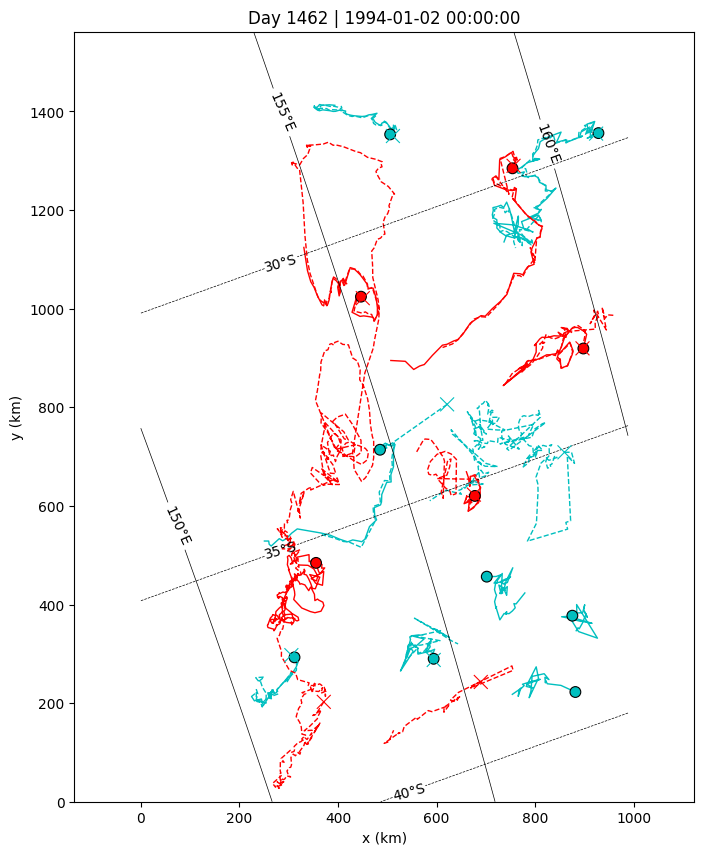

In [87]:
day_plot(1462+0, df_eddies, df_ameda, center_flag=False, out_core_flag=False)
         

In [78]:
df_ameda


,step,Date,type,lon,lat,shapes1,Eddy,calcul,large1,split,...,merge,merge2,shapes2,interaction,interaction2,xc,yc,Cyc,Day,Age
0,1.0,1994-01-02,1.0,161.023635,-29.730481,"Path(array([[161.69196902, -29.74776905],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,923.496286,1355.095118,CE,1462,97
1,2.0,1994-01-03,1.0,160.875116,-29.730481,"Path(array([[161.61770963, -29.62083127],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,909.687358,1350.117716,CE,1463,97
2,3.0,1994-01-04,1.0,160.912245,-29.77283,"Path(array([[161.61770963, -29.73193597],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,914.419542,1346.871154,CE,1464,97
3,4.0,1994-01-05,1.0,160.949375,-29.645783,"Path(array([[161.69196902, -29.45181181],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,914.029009,1361.587413,CE,1465,97
4,5.0,1994-01-06,1.0,160.875116,-29.603434,"Path(array([[161.65483933, -29.37574615],\n ...",1,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,905.835955,1363.586614,CE,1466,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155237,9185.0,2019-02-24,1.0,157.496314,-32.229073,"Path(array([[156.97649811, -30.91330759],\n ...",2257,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,677.415119,974.453518,CE,10646,30
155238,9186.0,2019-02-25,1.0,157.496314,-32.483167,"Path(array([[156.82797935, -32.91534144],\n ...",2257,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,685.414268,947.659272,CE,10647,30
155239,9187.0,2019-02-26,1.0,157.422054,-32.77961,"Path(array([[156.79084965, -32.92829222],\n ...",2257,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,688.040085,913.988839,CE,10648,30
155240,9188.0,2019-02-27,1.0,157.384925,-32.821959,"Path(array([[156.90223873, -32.77520238],\n ...",2257,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,686.037054,908.323210,CE,10649,30
